# 04 - Limitation Analysis

Analytical and empirical evidence for baseline limitations.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from core.production_model import ProductionUnit, STATE_NAMES
from core.network_model import InformationNetwork
from core.reliability_model import transmission_accuracy, rolling_failure_rate
from core.simulation_engine import SimulationEngine, SimulationConfig, summarize_by_time, performance_summary

OUTPUT_DIR = PROJECT_ROOT / 'outputs'
DATASET_DIR = OUTPUT_DIR / 'datasets'
GRAPH_DIR = OUTPUT_DIR / 'graphs'
LOG_DIR = OUTPUT_DIR / 'logs'
for directory in [DATASET_DIR, GRAPH_DIR, LOG_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

plt.style.use('seaborn-v0_8-whitegrid')

In [2]:
path = DATASET_DIR / 'baseline_dataset.csv'
if path.exists():
    df = pd.read_csv(path)
else:
    raw = SimulationEngine(SimulationConfig()).run(steps=600, runs=150, mode='baseline', seed=2026)
    raw['rolling_reliability_25'] = raw.groupby('run')['reliability'].transform(lambda s: s.rolling(25, min_periods=1).mean())
    raw['rolling_production_25'] = raw.groupby('run')['production_rate'].transform(lambda s: s.rolling(25, min_periods=1).mean())
    raw['failure_event'] = ((raw['failure'] == 1.0) & (raw.groupby('run')['failure'].shift(fill_value=0.0) == 0.0)).astype(int)
    df = raw

metrics = {
    'production_variance': df['production_rate'].var(),
    'failure_rate': 1.0 - df['reliability'].mean(),
    'load_reliability_correlation': df[['gateway_load', 'reliability']].corr().iloc[0, 1],
    'load_accuracy_correlation': df[['gateway_load', 'transmission_accuracy']].corr().iloc[0, 1],
}
pd.Series(metrics, name='baseline_limitation_metrics')

production_variance             0.049240
failure_rate                    0.448578
load_reliability_correlation    0.658791
load_accuracy_correlation      -0.995031
Name: baseline_limitation_metrics, dtype: float64

In [3]:
df['overloaded'] = df['gateway_load'] > SimulationConfig().gateway_capacity
overload_summary = df.groupby('overloaded').agg(
    reliability=('reliability', 'mean'),
    production_rate=('production_rate', 'mean'),
    transmission_accuracy=('transmission_accuracy', 'mean'),
    observations=('time', 'count'),
)
overload_summary

,reliability,production_rate,transmission_accuracy,observations
overloaded,,,,
False,0.066359,0.563792,0.520572,18837
True,0.679820,0.954323,0.411364,71163


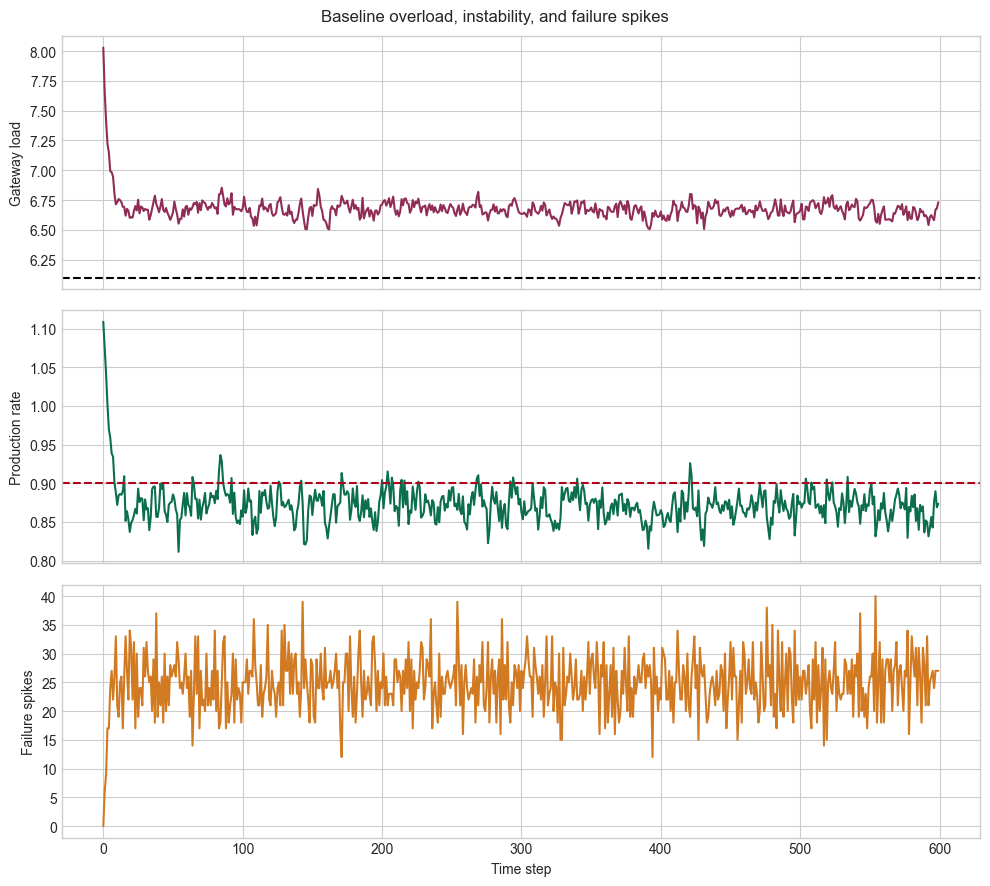

In [4]:
time_df = df.groupby('time', as_index=False).agg({
    'gateway_load': 'mean',
    'production_rate': 'mean',
    'reliability': 'mean',
    'failure_event': 'sum',
    'transmission_accuracy': 'mean',
})
fig, axes = plt.subplots(3, 1, figsize=(10, 9), sharex=True)
axes[0].plot(time_df['time'], time_df['gateway_load'], color='#8f2d56')
axes[0].axhline(SimulationConfig().gateway_capacity, color='black', linestyle='--')
axes[0].set_ylabel('Gateway load')
axes[1].plot(time_df['time'], time_df['production_rate'], color='#0b6e4f')
axes[1].axhline(SimulationConfig().demand, color='#b00020', linestyle='--')
axes[1].set_ylabel('Production rate')
axes[2].plot(time_df['time'], time_df['failure_event'], color='#d17a22')
axes[2].set_ylabel('Failure spikes')
axes[2].set_xlabel('Time step')
fig.suptitle('Baseline overload, instability, and failure spikes')
fig.tight_layout()
fig.savefig(GRAPH_DIR / '04_limitation_analysis.png', dpi=160)
plt.show()

## Conclusions

- Static decision policy: the baseline uses a fixed command even when the network is congested.
- No anticipation of failures: it does not forecast accuracy loss or overload persistence.
- No feedback correction: observed overload does not reduce future traffic.
- Inefficient under high load: overload reduces accuracy and delivered production, causing reliability loss.